In [1]:
import pandas as pd
import numpy as np

In [2]:
import seaborn as sna
import matplotlib.pyplot as plt

In [5]:
df=pd.read_csv("/content/drive/MyDrive/ai-impact-jobs-layoff-risk-dataset.csv")

In [6]:
df

,Age,Education_Level,Years_of_Experience,Industry,Job_Role,Company_Size,Job_Level,Routine_Task_Percentage,Creativity_Requirement,Human_Interaction_Level,AI_Adoption_Level,Number_of_AI_Tools_Used,AI_Usage_Hours_Per_Week,Tasks_Automated_Percentage,AI_Training_Hours,Layoff_Risk
0,59,Master's,6,Finance,Accountant,Medium,Entry,84,21,94,Medium,5,7,40,26,High
1,44,Master's,14,Manufacturing,Production Supervisor,Small,Entry,30,84,68,Low,2,2,14,9,Low
2,36,Bachelor's,7,Retail,Store Manager,Medium,Senior,12,86,71,Low,0,1,6,3,Low
3,27,Bachelor's,6,Finance,Auditor,Large,Entry,90,18,21,Medium,3,10,67,26,High
4,49,High School,12,Finance,Auditor,Small,Entry,49,52,72,Medium,5,13,26,19,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,56,Bachelor's,10,Retail,Sales Associate,Small,Entry,29,62,44,Low,0,4,16,0,Medium
19996,43,Bachelor's,9,Manufacturing,Production Supervisor,Medium,Entry,87,20,20,High,9,23,77,67,High
19997,28,High School,7,Telecom,Support Specialist,Medium,Entry,91,2,49,Medium,2,14,55,10,High
19998,46,Bachelor's,3,Manufacturing,Quality Engineer,Medium,Senior,76,40,89,Medium,3,13,66,5,Medium


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Age                         20000 non-null  int64 
 1   Education_Level             20000 non-null  object
 2   Years_of_Experience         20000 non-null  int64 
 3   Industry                    20000 non-null  object
 4   Job_Role                    20000 non-null  object
 5   Company_Size                20000 non-null  object
 6   Job_Level                   20000 non-null  object
 7   Routine_Task_Percentage     20000 non-null  int64 
 8   Creativity_Requirement      20000 non-null  int64 
 9   Human_Interaction_Level     20000 non-null  int64 
 10  AI_Adoption_Level           20000 non-null  object
 11  Number_of_AI_Tools_Used     20000 non-null  int64 
 12  AI_Usage_Hours_Per_Week     20000 non-null  int64 
 13  Tasks_Automated_Percentage  20000 non-null  in

In [8]:
df.describe()

,Age,Years_of_Experience,Routine_Task_Percentage,Creativity_Requirement,Human_Interaction_Level,Number_of_AI_Tools_Used,AI_Usage_Hours_Per_Week,Tasks_Automated_Percentage,AI_Training_Hours
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.00000,20000.000000
mean,40.361500,7.265500,51.885500,47.786700,60.055000,2.460350,6.77395,37.22895,12.621400
std,11.526333,4.720606,24.437808,26.100482,22.267801,2.097486,6.08637,19.99512,13.552647
min,21.000000,0.000000,10.000000,0.000000,20.000000,0.000000,0.00000,4.00000,0.000000
25%,30.000000,4.000000,31.000000,27.000000,41.000000,1.000000,2.00000,21.00000,4.000000
50%,40.000000,7.000000,52.000000,48.000000,62.000000,2.000000,5.00000,35.00000,8.000000
75%,50.000000,11.000000,73.000000,69.000000,79.000000,4.000000,10.00000,51.00000,18.000000
max,60.000000,32.000000,94.000000,100.000000,99.000000,10.000000,30.00000,93.00000,79.000000


In [9]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [10]:
cat_col=df.select_dtypes(include="object").columns

In [11]:
cat_col

Index(['Education_Level', 'Industry', 'Job_Role', 'Company_Size', 'Job_Level',
       'AI_Adoption_Level', 'Layoff_Risk'],
      dtype='object')

In [19]:
for val in cat_col:
  print(df[val].value_counts())
  print()
  df[val]=le.fit_transform(df[val])

Education_Level
Bachelor's     9967
Master's       5426
High School    3558
PhD            1049
Name: count, dtype: int64

Industry
Telecom          2582
Healthcare       2561
Finance          2513
Logistics        2488
IT               2483
Retail           2467
Manufacturing    2457
Education        2449
Name: count, dtype: int64

Job_Role
Nurse                    900
Medical Assistant        889
Financial Analyst        879
Support Specialist       873
Network Engineer         862
Operator                 858
Supply Chain Analyst     857
Inventory Analyst        857
Data Analyst             849
Operations Analyst       847
Warehouse Manager        843
Software Engineer        829
Accountant               821
Academic Coordinator     819
Research Assistant       818
Auditor                  813
Teacher                  812
Sales Associate          807
Production Supervisor    806
ML Engineer              805
Store Manager            803
Quality Engineer         793
Dispatcher        

In [20]:
df

,Age,Education_Level,Years_of_Experience,Industry,Job_Role,Company_Size,Job_Level,Routine_Task_Percentage,Creativity_Requirement,Human_Interaction_Level,AI_Adoption_Level,Number_of_AI_Tools_Used,AI_Usage_Hours_Per_Week,Tasks_Automated_Percentage,AI_Training_Hours,Layoff_Risk
0,59,2,6,1,1,1,0,84,21,94,2,5,7,40,26,0
1,44,2,14,5,14,2,0,30,84,68,1,2,2,14,9,1
2,36,0,7,6,19,1,2,12,86,71,1,0,1,6,3,1
3,27,0,6,1,2,0,0,90,18,21,2,3,10,67,26,0
4,49,1,12,1,2,2,0,49,52,72,2,5,13,26,19,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,56,0,10,6,17,2,0,29,62,44,1,0,4,16,0,2
19996,43,0,9,5,14,1,0,87,20,20,0,9,23,77,67,0
19997,28,1,7,7,21,1,0,91,2,49,2,2,14,55,10,0
19998,46,0,3,5,15,1,2,76,40,89,2,3,13,66,5,2


In [23]:
for val in cat_col:
  print((df[val].value_counts()))

Education_Level
0    9967
2    5426
1    3558
3    1049
Name: count, dtype: int64
Industry
7    2582
2    2561
1    2513
4    2488
3    2483
6    2467
5    2457
0    2449
Name: count, dtype: int64
Job_Role
11    900
9     889
5     879
21    873
10    862
13    858
20    857
7     857
3     849
12    847
23    843
18    829
1     821
0     819
16    818
2     813
22    812
17    807
14    806
8     805
19    803
15    793
4     788
6     772
Name: count, dtype: int64
Company_Size
1    8964
2    6066
0    4970
Name: count, dtype: int64
Job_Level
0    9016
1    7940
2    3044
Name: count, dtype: int64
AI_Adoption_Level
1    10539
2     8046
0     1415
Name: count, dtype: int64
Layoff_Risk
0    6797
1    6602
2    6601
Name: count, dtype: int64


In [24]:
df.isnull().sum()

,0
Age,0
Education_Level,0
Years_of_Experience,0
Industry,0
Job_Role,0
Company_Size,0
Job_Level,0
Routine_Task_Percentage,0
Creativity_Requirement,0
Human_Interaction_Level,0


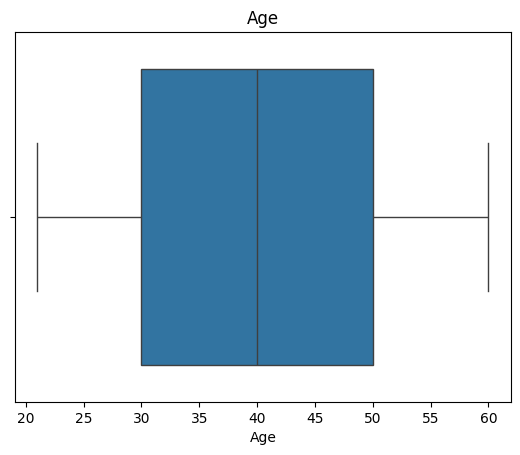

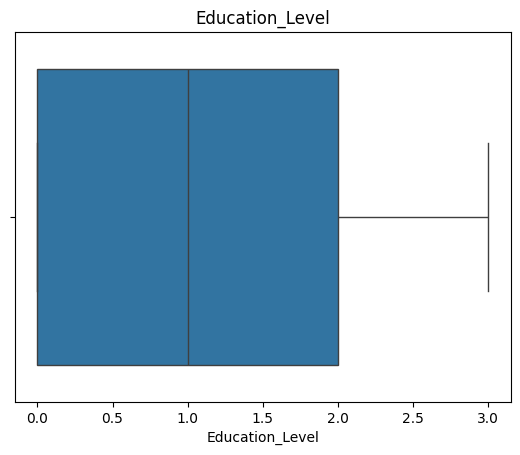

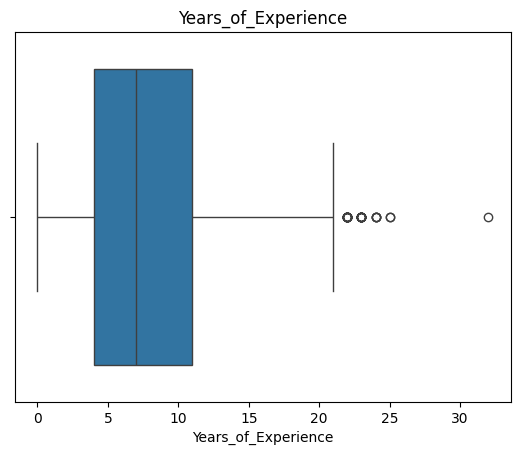

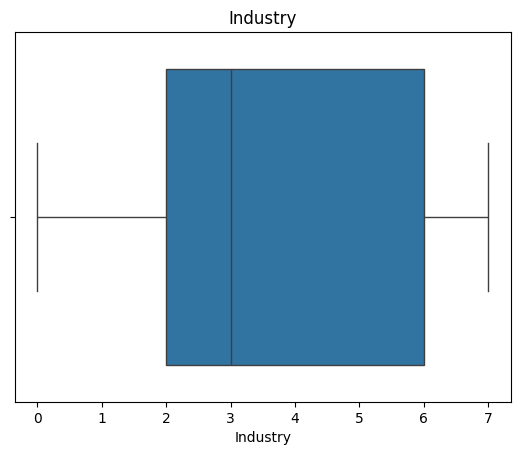

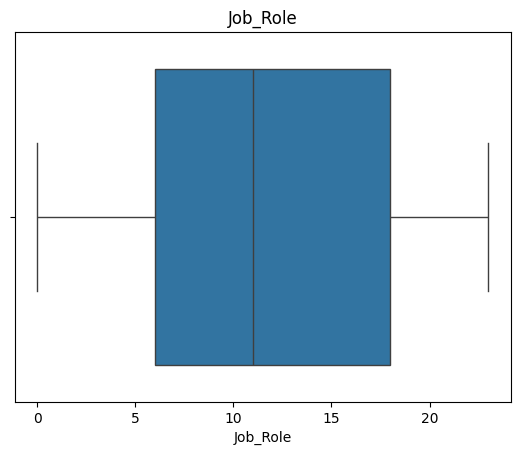

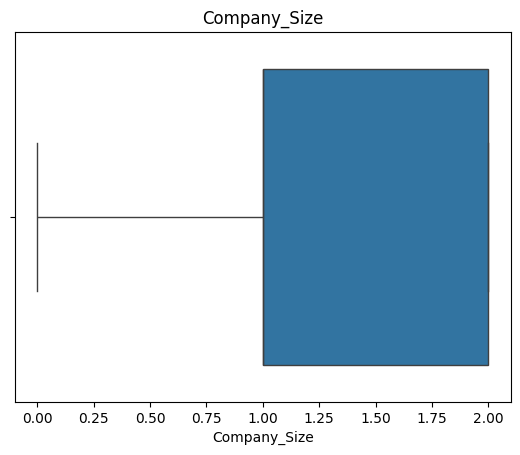

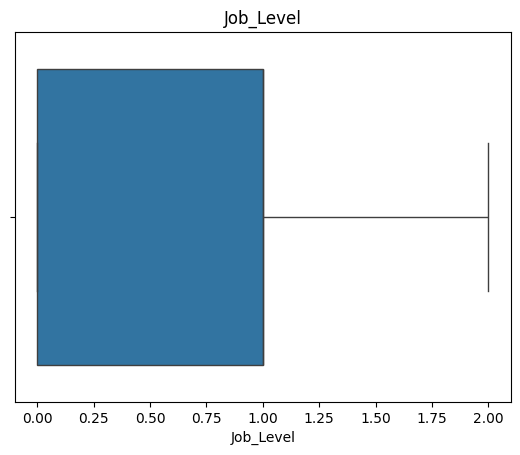

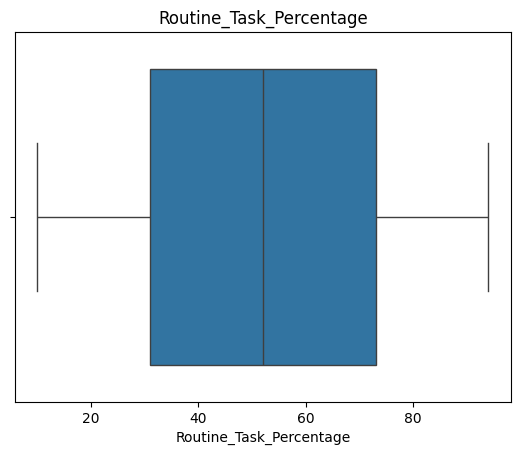

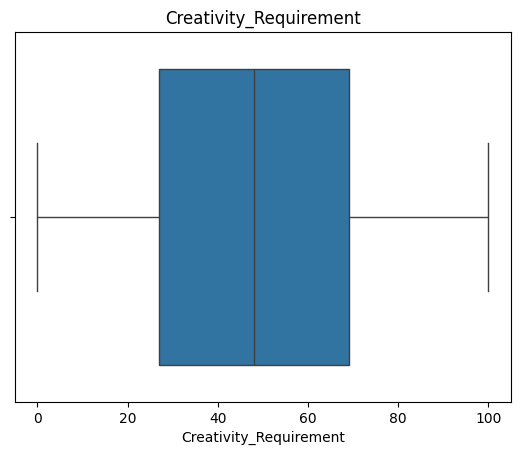

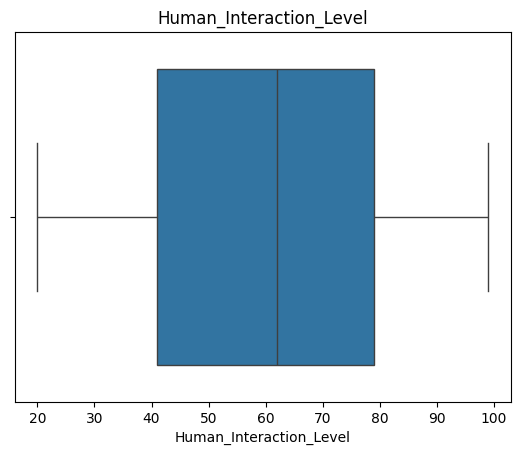

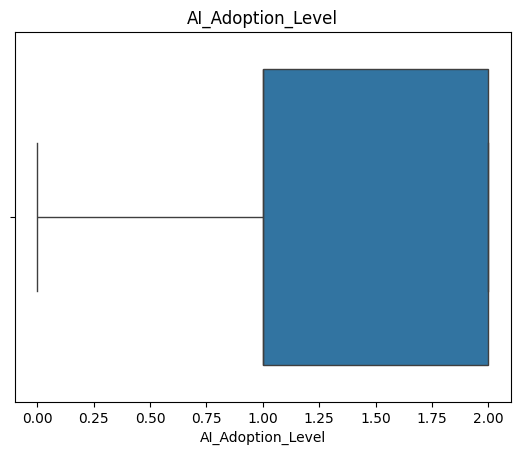

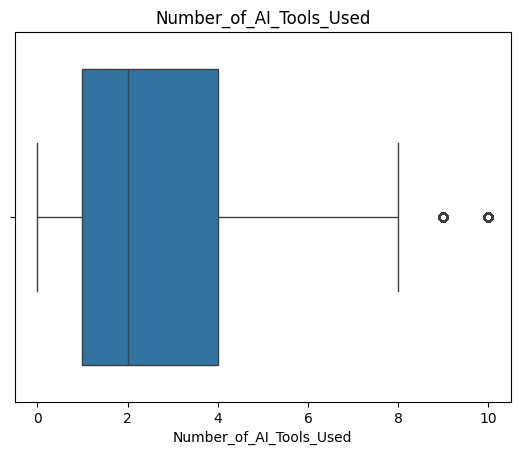

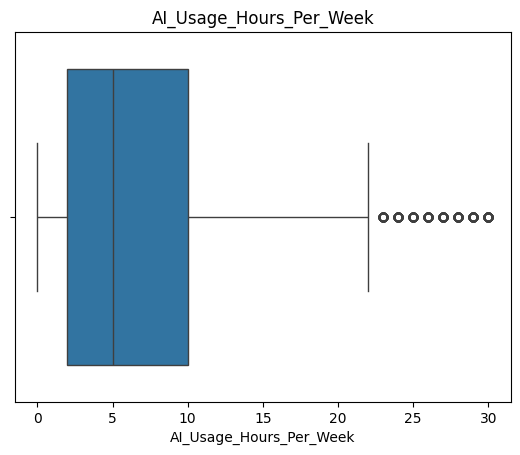

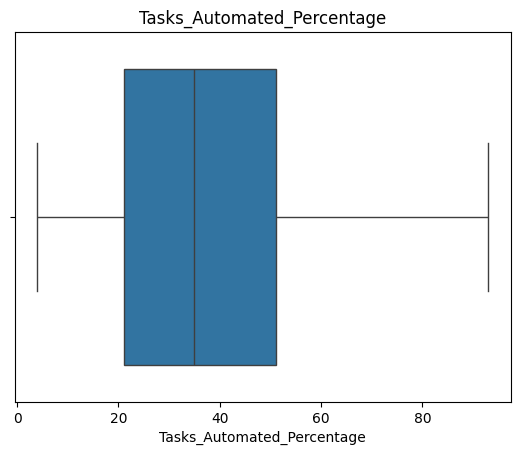

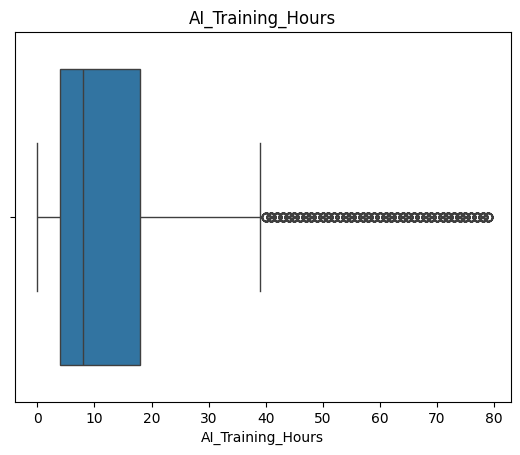

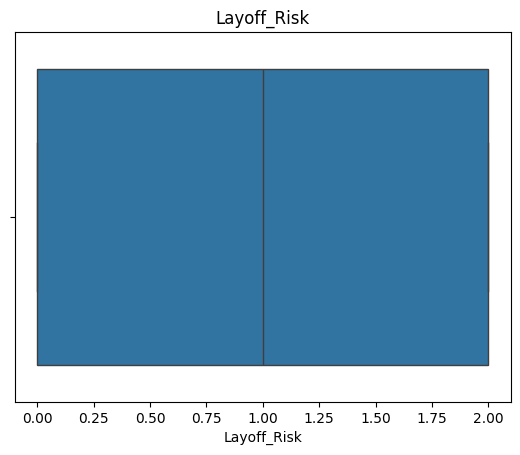

In [25]:
import seaborn as sns
for val in df.columns:
  plt.title(val)
  sns.boxplot(x=df[val])
  plt.show()

<Axes: >

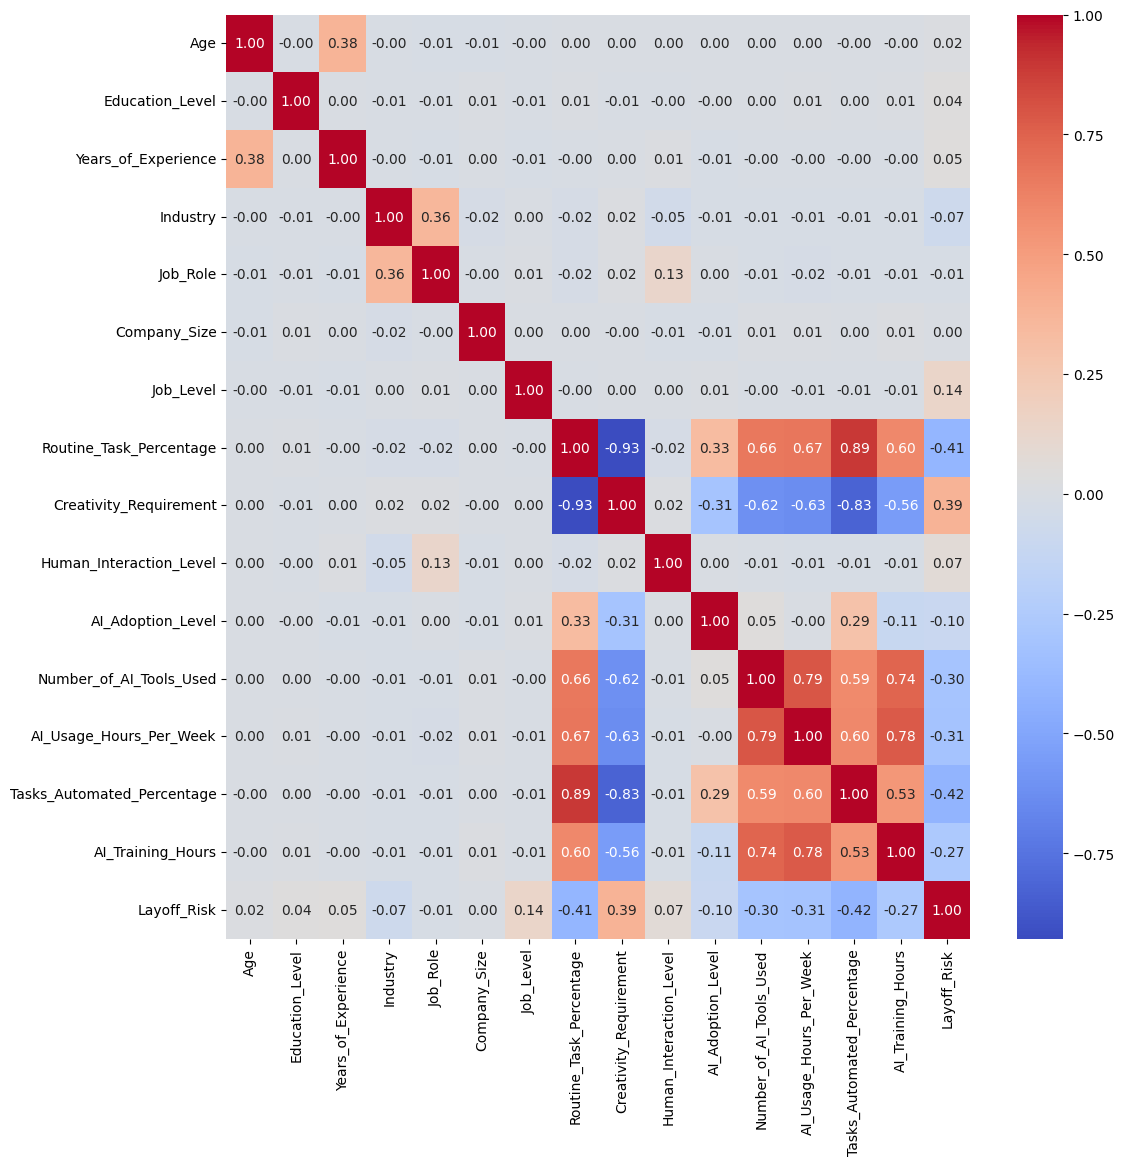

In [29]:
plt.figure(figsize=(12,12))
sns.heatmap(df.corr(), annot=True,fmt=".2f",cmap="coolwarm")

In [30]:
x=df.drop("Layoff_Risk",axis=1)
y=df["Layoff_Risk"]

In [31]:
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,StackingClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

In [32]:
from lightgbm import LGBMClassifier

In [34]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.0 MB/s eta 0:00:00


In [35]:
from catboost import CatBoostClassifier

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix

In [39]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=25,stratify=y)

In [40]:
#for ADAboost
stump=DecisionTreeClassifier(max_depth=1)

In [41]:
adaboost=AdaBoostClassifier(estimator=stump,learning_rate=0.02,n_estimators=120,random_state=28)

In [42]:
base_models = [
    ('rf', RandomForestClassifier()),
    ('xgb', XGBClassifier()),
    ('knn', KNeighborsClassifier())
]
stack=StackingClassifier(estimators=base_models,final_estimator=LogisticRegression())

In [56]:
#Random forest (bagging)
model_random=RandomForestClassifier(n_estimators=150,criterion="entropy",random_state=29)

In [57]:
model_random.fit(x_train,y_train)

RandomForestClassifier(criterion='entropy', n_estimators=150, random_state=29)

In [58]:
y_pred_random=model_random.predict(x_test)

In [59]:
acc_score_random=accuracy_score(y_test,y_pred_random)
acc_score_random

0.8935

In [60]:
print(classification_report(y_test,y_pred_random))

              precision    recall  f1-score   support

           0       0.92      0.92      0.92      1360
           1       0.93      0.92      0.92      1320
           2       0.83      0.85      0.84      1320

    accuracy                           0.89      4000
   macro avg       0.89      0.89      0.89      4000
weighted avg       0.89      0.89      0.89      4000



In [61]:
#Boosting
#AdaBoost
adaboost.fit(x_train,y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                   learning_rate=0.02, n_estimators=120, random_state=28)

In [62]:
y_pred_ada=adaboost.predict(x_test)

In [63]:
acc_score_ada=accuracy_score(y_test,y_pred_ada)
print(acc_score_ada)
print(classification_report(y_test,y_pred_ada))

0.6615
              precision    recall  f1-score   support

           0       0.69      0.91      0.78      1360
           1       0.65      0.88      0.75      1320
           2       0.60      0.19      0.29      1320

    accuracy                           0.66      4000
   macro avg       0.65      0.66      0.61      4000
weighted avg       0.65      0.66      0.61      4000



In [64]:
#gradientBoost
gradient=GradientBoostingClassifier(learning_rate=0.05,n_estimators=200,random_state=80)

In [65]:
gradient.fit(x_train,y_train)

GradientBoostingClassifier(learning_rate=0.05, n_estimators=200,
                           random_state=80)

In [66]:
y_pred_gra=gradient.predict(x_test)

In [67]:
acc_score_gra=accuracy_score(y_test,y_pred_gra)
print(acc_score_gra)
print(classification_report(y_test,y_pred_gra))

0.904
              precision    recall  f1-score   support

           0       0.93      0.92      0.93      1360
           1       0.95      0.91      0.93      1320
           2       0.84      0.88      0.86      1320

    accuracy                           0.90      4000
   macro avg       0.91      0.90      0.90      4000
weighted avg       0.91      0.90      0.90      4000



In [69]:
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(x_train, y_train)

xgb_pred = xgb.predict(x_test)

In [70]:
xgb_pred

array([1, 1, 1, ..., 1, 2, 2])

In [71]:
acc_score_xgb=accuracy_score(y_test,xgb_pred)
acc_score_xgb

0.928

In [73]:
lgbm = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

lgbm.fit(x_train, y_train)

lgbm_pred = lgbm.predict(x_test)
acc_score_lgbm=accuracy_score(y_test,lgbm_pred)
acc_score_lgbm

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012960 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 593
[LightGBM] [Info] Number of data points in the train set: 16000, number of used features: 15
[LightGBM] [Info] Start training from score -1.079361
[LightGBM] [Info] Start training from score -1.108284
[LightGBM] [Info] Start training from score -1.108473
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

0.9345

In [74]:
cat = CatBoostClassifier(
    iterations=200,
    learning_rate=0.05,
    depth=5,
    verbose=0,
    random_state=42
)

cat.fit(x_train, y_train)

cat_pred = cat.predict(x_test)
acc_score_cat=accuracy_score(y_test,cat_pred)
acc_score_cat

0.925

In [75]:
stack.fit(x_train, y_train)

stack_pred = stack.predict(x_test)

In [76]:
acc_score_stack=accuracy_score(y_test,stack_pred)
acc_score_stack


0.9425

In [77]:
models = {
    "Random Forest": model_random,
    "AdaBoost": adaboost,
    "Gradient Boosting": gradient,
    "XGBoost": xgb,
    "LightGBM": lgbm,
    "CatBoost": cat,
    "Stacking": stack
}


In [79]:
results = []

for name, model in models.items():

    y_pred = model.predict(x_test)

    acc = accuracy_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": acc
    })

results_df = pd.DataFrame(results)

results_df.sort_values(
    by="Accuracy",
    ascending=False,
    inplace=True
)

print(results_df)

               Model  Accuracy
6           Stacking    0.9425
4           LightGBM    0.9345
3            XGBoost    0.9280
5           CatBoost    0.9250
2  Gradient Boosting    0.9040
0      Random Forest    0.8935
1           AdaBoost    0.6615
